# Introduction to parametrised stochastic circuits


<div class="note"><span class="note-t">TL;DR</span>
<p>We tour Torx's gates over pbits, pdits, and pmodes, building the smallest circuit per gate. We connect each constructor to its transition kernel or Gaussian map, sample pbit and pmode circuits, and read the pdit kernel from its transition matrix.</p>
</div>

In this tutorial, we build parametrised stochastic circuits (PSCs) and run them on the three Torx data primitives. Torx is a JAX framework for programs that transform probability distributions, so a circuit here is a recipe for reshaping a distribution. This notebook is the entry point to the example gallery; the gates and sampling workflow here reappear throughout the later notebooks. The examples assume basic familiarity with probability distributions and JAX, and use Torx, JAX, NumPy, and Matplotlib.

By the end, you'll be able to:

- build a PSC from gates,
- read each gate as a transition kernel, and
- sample pbit and pmode circuits and read the pdit kernel from its transition matrix.

The three data primitives are:

- pbits, binary sites, $\{0,1\}$,
- pdits, $d$-state sites, $\{0,\dots,d-1\}$, and
- pmodes, continuous sites, $\mathbb{R}^N$.

We build a PSC from scratch and meet the core gates for each primitive:

1. pbit gates `PSWAP`, `PNOT`, and `PISING`, reading each transition matrix and sampling the branch gates,
2. the pdit gate that takes a stay/forward/backward random walk on its $d$ states, and
3. pmode gates `AffineGaussianGate` and `MixtureGaussianGate`.



## Setup

We first configure the helper path, the shared plotting style, and the `savefig` utility used throughout.

In [1]:
from pathlib import Path
import sys

import jax
import jax.numpy as jnp
import numpy as np
from jax.scipy.special import logit

# Resolve examples/helpers whether run from repo root or examples.
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))

In [2]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_fields as P_fld
import _plots_schematics as P_sch

apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
savefig = make_savefig(FIGURE_DIR)

## Pbit gates

A **pbit** (probabilistic bit) is a binary stochastic site: at any instant it is 0 or 1 with some probability. A joint configuration is written as a ket, $|ab)$ with $a,b\in\{0,1\}$, a label for one of the $2^2=4$ basis configurations of two pbits ($n$ pbits have $2^n$).

A gate over pbits is a column-stochastic kernel $K(y\mid x)$ on these configurations, with $\sum_y K(y\mid x)=1$. Read it by column: column $x$ holds the distribution over outputs $y$ given the input $|x)$.

The branch-table pbit gates `PSWAP` and `PNOT` have two branches: leave the pbit unchanged, or apply a deterministic operation $B$. The operation branch is selected with probability $p$:

$$G(\theta)=\underbrace{(1-\sigma(\theta))\,I}_{\vphantom{\big|}\text{stay branch}}+\underbrace{\sigma(\theta)\,B}_{\vphantom{\big|}\text{op branch}},\qquad p=\sigma(\theta)=\frac{1}{1+e^{-\theta}}.$$

Torx parametrises these branch gates by the logit $\theta=\log\frac{p}{1-p}$, which ranges over all of $\mathbb{R}$ and works cleanly with gradients; applying the sigmoid recovers the physical switching probability $p$.

`PISING`, introduced below, is the energy-based exception: its parameter vector defines an Ising bond update rather than a single switching logit.

Throughout this section we fix the switching probability at $p=0.30$.

Next, we import the circuit and simulator classes along with the binary gates, and define the shared demo logit, sample count, and random number generator keys.

In [3]:
from torx.psc import DiscretePCircuit, BranchingSimulator
from torx.psc import PSWAP, PNOT

# Keep one probability across the simple gate demos so their plots are comparable.
P_DEMO = 0.30
DEMO_SAMPLES = 20000
# Gates are structure only; their parameters live in a separate `thetas` list,
# one entry per gate aligned with `circuit.gates`. The two-branch gates here
# take a length-1 logit vector, matching `circuit.init_params`.
THETA_DEMO = jnp.array([logit(P_DEMO)])
# explicit per-draw keys keep each sampling cell idempotent under re-runs
DEMO_KEYS = jax.random.split(jax.random.key(11), 4)

We create the shared `BranchingSimulator` and define `sample_distribution`: given a compiled circuit (each gate demo compiles its circuit once), it calls `sample` and returns empirical probabilities for each output state.

In [4]:
demo_sim = BranchingSimulator(num_samples=DEMO_SAMPLES)


def sample_distribution(compiled, initial, num_states, key):
    """Run the compiled circuit on `initial`, return the empirical distribution."""
    samples = np.asarray(
        demo_sim.sample(compiled, jnp.asarray(initial, dtype=jnp.int32), key)
    )
    states = np.ravel_multi_index(samples.T, (num_states,) * samples.shape[1])
    return np.bincount(states, minlength=num_states ** samples.shape[1]) / len(states)

### PSWAP

With probability $p$, `PSWAP` swaps two pbits, and otherwise it leaves them alone. Only $|01)$ and $|10)$ change, and $|00)$ and $|11)$ are fixed points:

$$\mathsf{PSWAP}(p)\,|ab)=(1-p)\,|ab)+p\,|ba).$$

In the basis $(|00), |01), |10), |11))$ that is the column-stochastic matrix:

$$\mathsf{PSWAP}(p)=\begin{pmatrix}1 & 0 & 0 & 0\\ 0 & 1-p & p & 0\\ 0 & p & 1-p & 0\\ 0 & 0 & 0 & 1\end{pmatrix}.$$

Below we build the one-gate circuit, compile it once for both inputs, and draw the diagram: a single `PSWAP` gate acting on two pbits.

In [5]:
circuit = DiscretePCircuit([PSWAP([0, 1])])
# One parameter vector per gate, in gate order.
thetas = [THETA_DEMO]
# compile once and reuse across both input states
pswap_compiled = demo_sim.build_circuit(circuit, thetas)

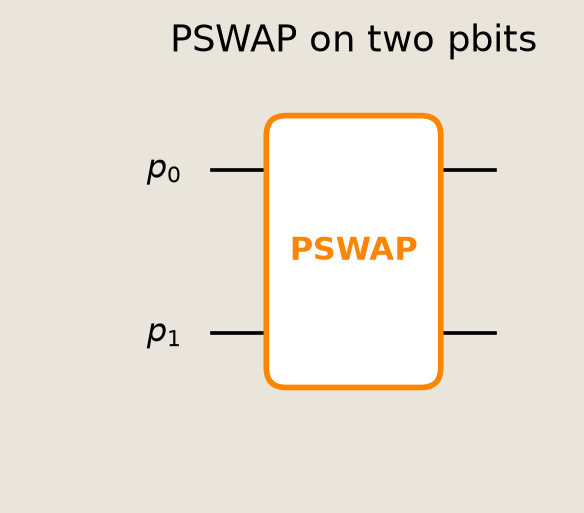

In [6]:
fig = P_sch.draw_pcircuit(
    circuit, wire_labels=[r"$p_0$", r"$p_1$"], title="PSWAP on two pbits"
)
savefig(fig, "01_circuit_pswap")

We sample the two changeable inputs to make the stay and swap branches visible.

In [7]:
labels = ["00", "01", "10", "11"]
# Only |01) and |10) can move under PSWAP; the other basis states are fixed.
dists = [
    (
        "input |01)",
        labels,
        sample_distribution(pswap_compiled, [0, 1], num_states=2, key=DEMO_KEYS[0]),
    ),
    (
        "input |10)",
        labels,
        sample_distribution(pswap_compiled, [1, 0], num_states=2, key=DEMO_KEYS[1]),
    ),
]

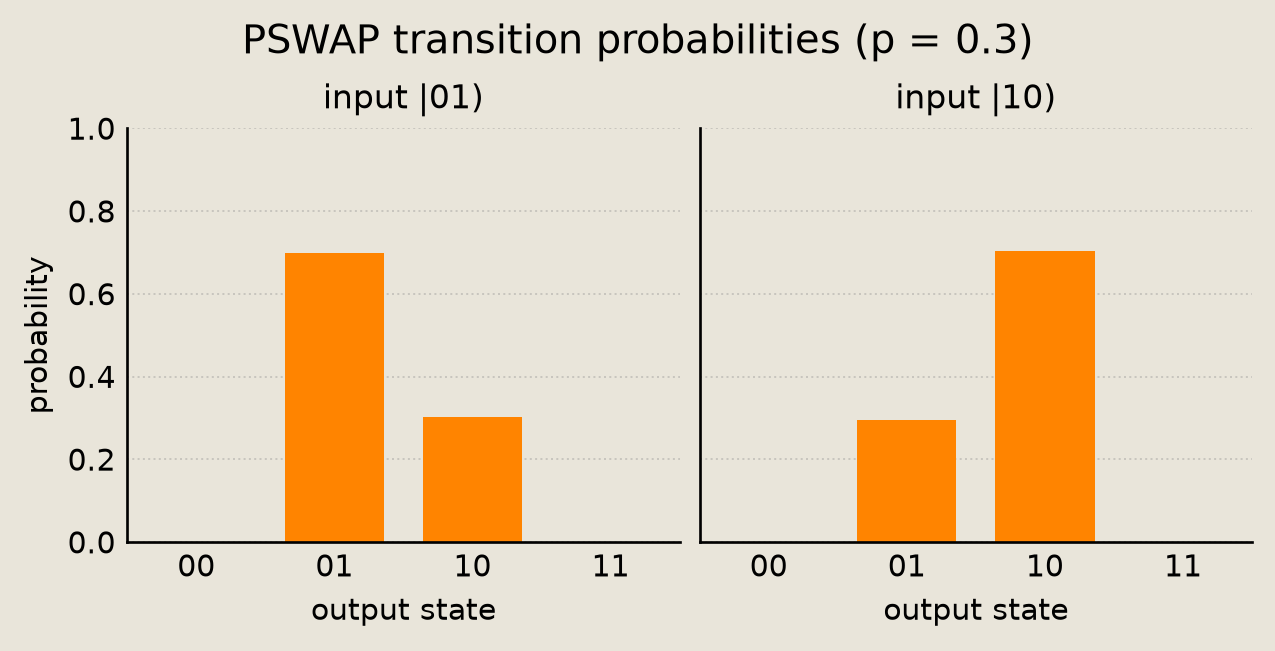

In [8]:
fig = P_sch.transition_bars(dists, gate="PSWAP", p=P_DEMO)
savefig(fig, "01_gate_pswap")

### PNOT

With probability $p$, `PNOT` flips one pbit, and otherwise the bit is unchanged. Its kernel is the convex combination (a probability-weighted blend) of $I$ and the NOT operation:

$$\mathsf{PNOT}(p)=\begin{pmatrix}1-p & p\\ p & 1-p\end{pmatrix}.$$

The sampled distributions below show both possible inputs and their flipped and unchanged outcomes.

In [9]:
circuit = DiscretePCircuit([PNOT(0)])
thetas = [THETA_DEMO]
pnot_compiled = demo_sim.build_circuit(circuit, thetas)
labels = ["0", "1"]
dists = [
    (
        "input |0)",
        labels,
        sample_distribution(pnot_compiled, [0], num_states=2, key=DEMO_KEYS[2]),
    ),
    (
        "input |1)",
        labels,
        sample_distribution(pnot_compiled, [1], num_states=2, key=DEMO_KEYS[3]),
    ),
]

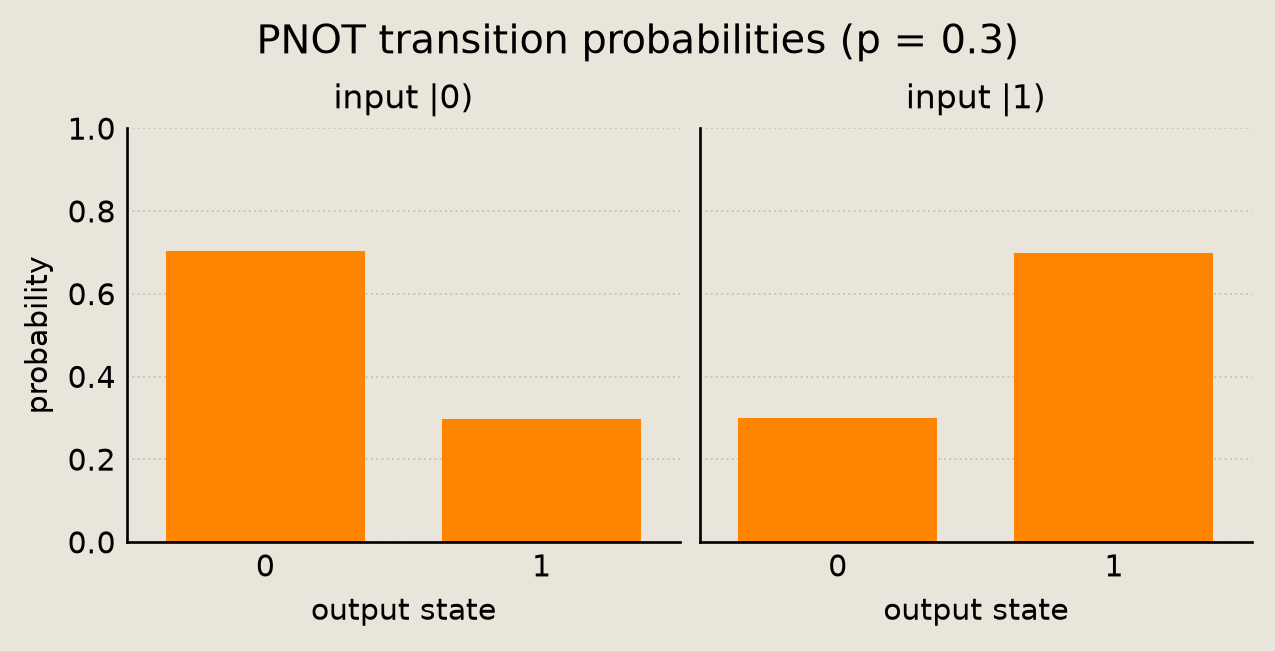

In [10]:
fig = P_sch.transition_bars(dists, gate="PNOT", p=P_DEMO)
savefig(fig, "01_gate_pnot")

### PISING

The `PISING` gate is a finite-time continuous-time Glauber kernel on an Ising bond: it integrates a single-spin-flip Glauber generator for a time $\Delta t$, so the resulting kernel includes multi-flip paths.

With $s_i=2b_i-1$ for pbit values $b_i\in\{0,1\}$, the bond energy and the single-flip Glauber generator are:

$$E(\mathbf{s})=-J\,s_1 s_2-h_1 s_1-h_2 s_2,\qquad
Q_{ab}=\mathbb{1}[\mathrm{Hamming}(a,b)=1]\;\sigma\left[-\beta\big(E_a-E_b\big)\right]\ (a\neq b),\qquad
Q_{bb}=-\!\!\sum_{a\neq b}Q_{ab},$$

so only single-spin-flip neighbors get off-diagonal rates and each column sums to zero. Here $J$ is the bond coupling and $h_1, h_2$ are the local fields. The inverse temperature $\beta$ scales the energy change of the proposed flip, so larger $\beta$ means a colder, more selective update.

The gate itself is the matrix exponential $\mathsf{PISING}(\theta)=\exp(\Delta t\,Q)$. Unlike the branch-table gates above, it is a $4\times 4$ column-stochastic kernel. Its parameter vector $\theta=[J,h_1,h_2,\beta,\Delta t]$ holds the physical bond parameters.

We build the gate, evaluate its transition matrix with `get_matrix`, and plot it as a heatmap for the chosen bond parameters. The multi-flip entries are positive but small, and at $\Delta t=0.35$ they round to 0.00 in the heatmap.

In [11]:
from torx.psc import PISING

In [12]:
# Parameters are [J, h1, h2, beta, dt] for this two-site Ising update.
gate = PISING([0, 1])
theta = jnp.array([1.0, 0.0, 0.0, 1.5, 0.35])
M = np.asarray(gate.get_matrix(theta))

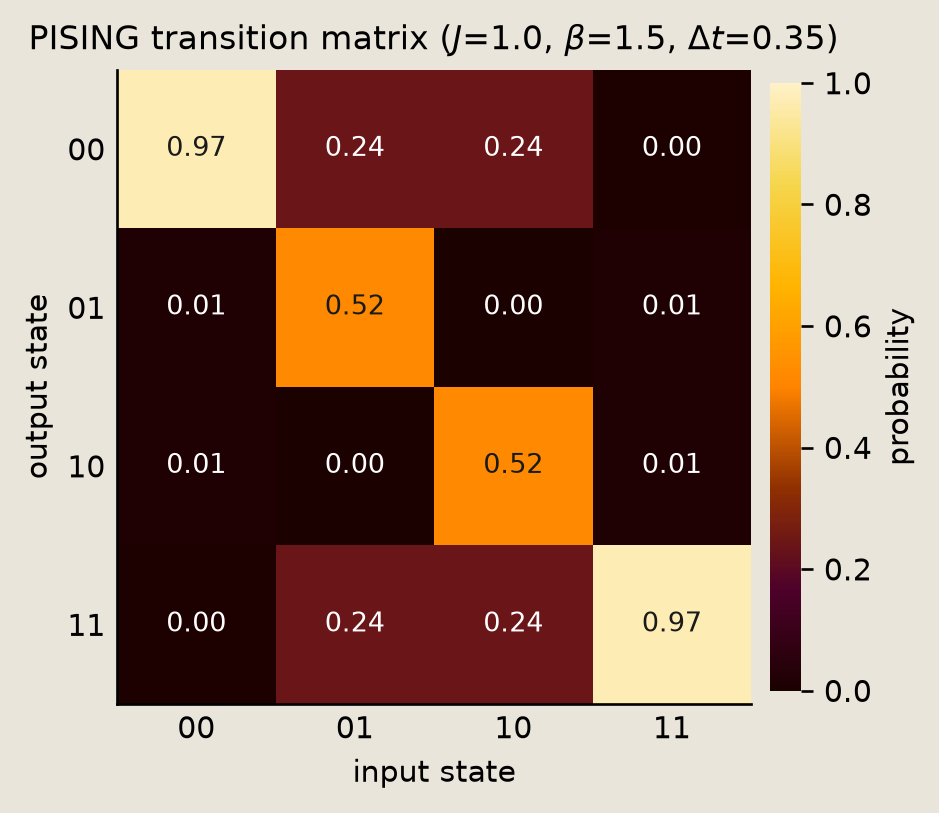

In [13]:
fig = P_sch.ising_matrix(M, J=1.0, beta=1.5, dt=0.35)
savefig(fig, "01_gate_pising")

## Pdit gates

A **pdit** is a discrete stochastic site with $d$ states, the generalization of a pbit to more than two states. We use `PditCycle`, a random walk on a cyclic $d$-state pdit with stay, forward, and backward branches. The heatmap below is its column-stochastic transition matrix at $d=3$.

Other pdit permutation gates include `PditShift` and `PditSWAP`, and `PditCycle` drives the regime chain in notebook 13.

In [14]:
from torx.psc import PditCycle

In [15]:
DIMS = 3
cycle_theta = jnp.log(
    jnp.array([0.30 / 0.50, 0.20 / 0.50])
)  # stay=0.50, forward=0.30, backward=0.20
matrices = [
    ("PditCycle", np.asarray(PditCycle(sites=0, dims=DIMS).get_matrix(cycle_theta))),
]

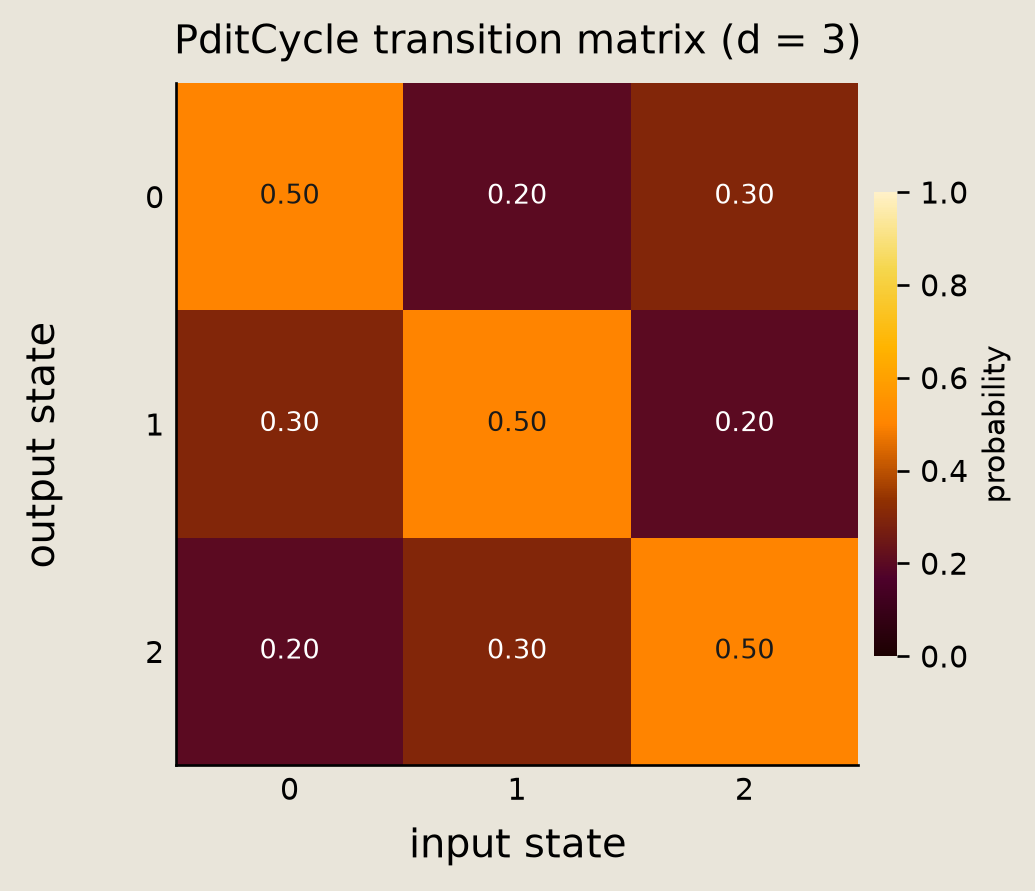

In [16]:
fig = P_sch.pdit_matrices(matrices, dims=DIMS)
savefig(fig, "01_gate_pdit")

## Pmode gates

A **pmode** is a continuous stochastic site valued in $\mathbb{R}^N$. `AffineGaussianGate` is the general pmode gate we use here: it applies a linear map, adds a bias, and adds diagonal Gaussian noise. This form maps Gaussian inputs to Gaussian outputs:

$$X \mapsto \underbrace{A X}_{\vphantom{\big|}\text{linear map}} + \mathbf{b} + \varepsilon,\qquad \varepsilon \sim \mathcal{N}(0, \Delta),$$

where $A$ is the linear map, $\mathbf{b}$ the bias shift, and $\varepsilon$ the diagonal Gaussian noise. On a Gaussian input this is closed form: $\mathcal{N}(\mu,\Sigma)\mapsto\mathcal{N}(A\mu+\mathbf{b},\,A\Sigma A^\top+\Delta)$.

The examples below use `AffineGaussianGate` directly, then `MixtureGaussianGate`, which selects one of several diagonal Gaussian components (a mean shift plus diagonal noise) under a discrete control.

`AffineGaussianGate` already covers the common special cases: shift, scale, rotation, and diffusion.

### AffineGaussianGate

We apply one `AffineGaussianGate` to an $\mathcal{N}(0, I)$ input cloud and watch the distribution move: the linear map stretches and tilts it, the bias shifts it, and the diagonal noise sets the spread. The scatter plot compares the input cloud with the transformed one. The next cell defines `sample_continuous`, which compiles a circuit and samples its cloud from the origin.

See [`10_pmode_gaussian_gates.ipynb`](10_pmode_gaussian_gates.ipynb) for the full pmode-gate tour: the specialized `Displace`, `Scale`, `Mix`, and `Diffuse` gates, the exact moment and composition laws, closed-form conditioning, and the analytic-versus-sampled checks.

In [17]:
from torx.psc import (
    AffineGaussianGate,
    MixtureGaussianGate,
    HybridPCircuit,
)

# A source gate injects the N(0, I) input cloud from one initial state.
PMODE_SAMPLES = 1500


def sample_continuous(circuit, thetas, key, num_continuous=2):
    """Compile `circuit` with `thetas`, run it from the origin, return the cloud."""
    origin = {
        "discrete": jnp.zeros(0, dtype=jnp.int32),
        "continuous": jnp.zeros(num_continuous),
    }
    out = circuit.sample_multiple(key, origin, thetas, n_samples=PMODE_SAMPLES)
    return np.asarray(out["continuous"])

In [18]:
# A simple affine map: a linear stretch-and-tilt, a bias shift, and a little
# diagonal Gaussian noise. The point here is only that a pmode gate reshapes a
# distribution; the detailed gate tour lives in `10_pmode_gaussian_gates.ipynb`.
A_demo = np.array([[1.3, 0.5], [0.0, 0.7]], dtype=np.float32)
b_demo = np.array([0.6, -0.4], dtype=np.float32)
log_var_demo = np.array([np.log(0.05), np.log(0.05)], dtype=np.float32)

In [19]:
affine_gate = AffineGaussianGate(
    sites=[0, 1],
    dims=(1, 1),
)
# Parameters are separate from the gate structure.
affine_params = {
    "A": jnp.asarray(A_demo),
    "b": jnp.asarray(b_demo),
    "log_var": jnp.asarray(log_var_demo),
}

# A second affine-Gaussian gate at its default identity params (A = I, b = 0,
# log_var = 0) is the source that emits the N(0, I) input cloud, so the input
# and output clouds both come out of Torx circuits.
source_gate = AffineGaussianGate(sites=[0, 1], dims=(1, 1))
source_params = source_gate.init_params(jax.random.key(0))

input_circuit = HybridPCircuit([source_gate])
affine_circuit = HybridPCircuit([source_gate, affine_gate])

In [20]:
# The source circuit emits N(0, I); the source + affine circuit transforms it.
in_cloud = sample_continuous(input_circuit, [source_params], jax.random.key(1000))
out_cloud = sample_continuous(
    affine_circuit, [source_params, affine_params], jax.random.key(1001)
)

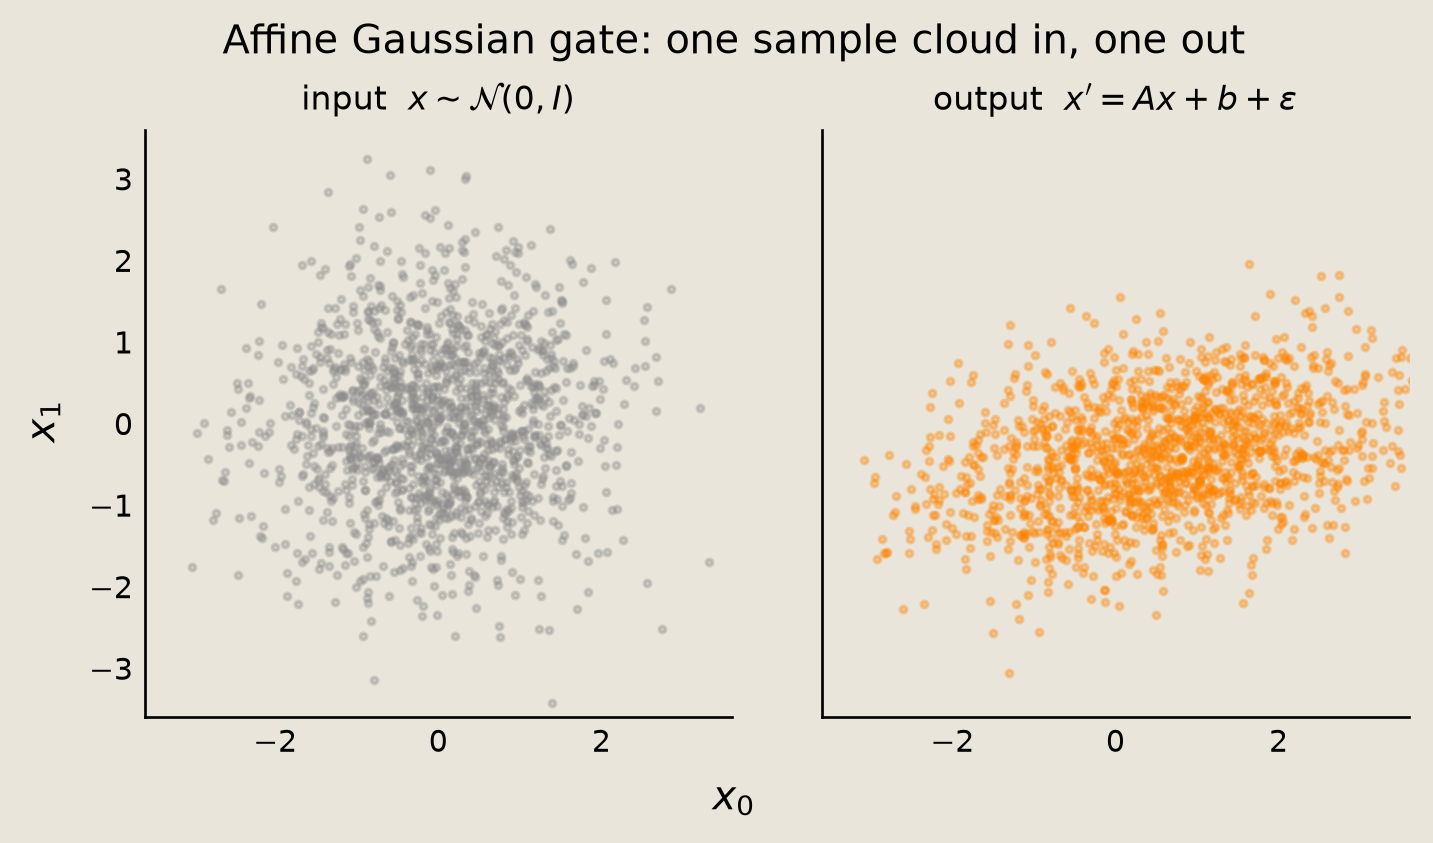

In [21]:
fig = P_fld.affine_gaussian_clouds(in_cloud, out_cloud)
savefig(fig, "01_gate_affine_gaussian")

The output cloud shows the affine map and diagonal noise applied to an $\mathcal{N}(0, I)$ input drawn from a separate source circuit with its own key, so its points have no one-to-one correspondence with the plotted input points.

### MixtureGaussianGate

`MixtureGaussianGate` uses the control pdit value to choose which diagonal Gaussian component fires. The gate adds the selected component mean (plus diagonal Gaussian noise) to the input continuous state. We start the pmode at the origin and sample the control from known weights $\pi$, so the marginal cloud follows the mixture density:

$$p_{X'}(x)=\sum_{k=0}^{K-1}\pi_k\,\mathcal{N}(x;\,\mu_k,\,\Sigma_k),$$

where $\pi_k$ is the control distribution (how often branch $k$ fires), $\mu_k$ is branch $k$'s mean, and $\Sigma_k=\mathrm{diag}(\sigma_k^2)$ is its diagonal covariance. Before plotting, we check the per-branch sample means and empirical branch weights against the parameters. The sampled control label colors each point, and the contour overlay is the analytic mixture density.

In [22]:
def sample_mixture(circuit, thetas, key):
    """Sample the marginal mixture by drawing the control inside the circuit."""
    initial = {
        "discrete": jnp.array([0], dtype=jnp.int32),
        "continuous": jnp.zeros(2),
    }
    out = circuit.sample_multiple(key, initial, thetas, n_samples=MIXTURE_SAMPLES)
    samples = np.asarray(out["continuous"])
    labels = np.asarray(out["discrete"])[:, 0]
    return samples, labels


def mixture_density_grid(means, sigmas, weights, samples, pad=0.45, n=120):
    """Evaluate the analytic diagonal-Gaussian mixture on a 2D grid."""
    lo = samples.min(axis=0) - pad
    hi = samples.max(axis=0) + pad
    x0 = np.linspace(lo[0], hi[0], n)
    x1 = np.linspace(lo[1], hi[1], n)
    xx, yy = np.meshgrid(x0, x1)
    pts = np.stack([xx, yy], axis=-1)
    density = np.zeros(xx.shape)
    for weight, mean, sigma in zip(weights, means, sigmas):
        z = (pts - np.asarray(mean)) / np.asarray(sigma)
        norm = 1.0 / (2.0 * np.pi * np.prod(sigma))
        density += float(weight) * norm * np.exp(-0.5 * np.sum(z**2, axis=-1))
    return xx, yy, density

In [23]:
K = 3
mix_means = jnp.array([[-1.2, 0.0], [0.4, 0.8], [1.0, -0.6]], dtype=jnp.float32)
mix_sigmas = np.array([[0.18, 0.18], [0.20, 0.15], [0.16, 0.22]], dtype=np.float32)
mix_probs = jnp.array([0.50, 0.30, 0.20], dtype=jnp.float32)

In [24]:
mixture_gate = MixtureGaussianGate(
    sites=(0, 0),
    dims=(2,),
    num_components=K,
)
mixture_params = {
    "means": mix_means,
    "log_vars": jnp.log(jnp.asarray(mix_sigmas**2)),
}
# Starting at control 0, PditCycle maps stay/forward/backward to components 0/1/2.
control_gate = PditCycle(sites=0, dims=K)
control_theta = jnp.log(mix_probs[1:] / mix_probs[0])

mixture_circuit = HybridPCircuit([control_gate, mixture_gate])
MIXTURE_SAMPLES = 800

In [25]:
samples, labels = sample_mixture(
    mixture_circuit, [control_theta, mixture_params], jax.random.key(99)
)
branch_counts = np.bincount(labels, minlength=K)
assert branch_counts.min() > 0
for k in range(K):
    # finite-sample
    tol = 5.0 * mix_sigmas[k].max() / np.sqrt(branch_counts[k])
    err = np.max(np.abs(samples[labels == k].mean(0) - np.asarray(mix_means[k])))
    assert err < tol, (k, err, tol)
empirical_weights = branch_counts / branch_counts.sum()
assert np.max(np.abs(empirical_weights - np.asarray(mix_probs))) < 3.0 / np.sqrt(
    MIXTURE_SAMPLES
)

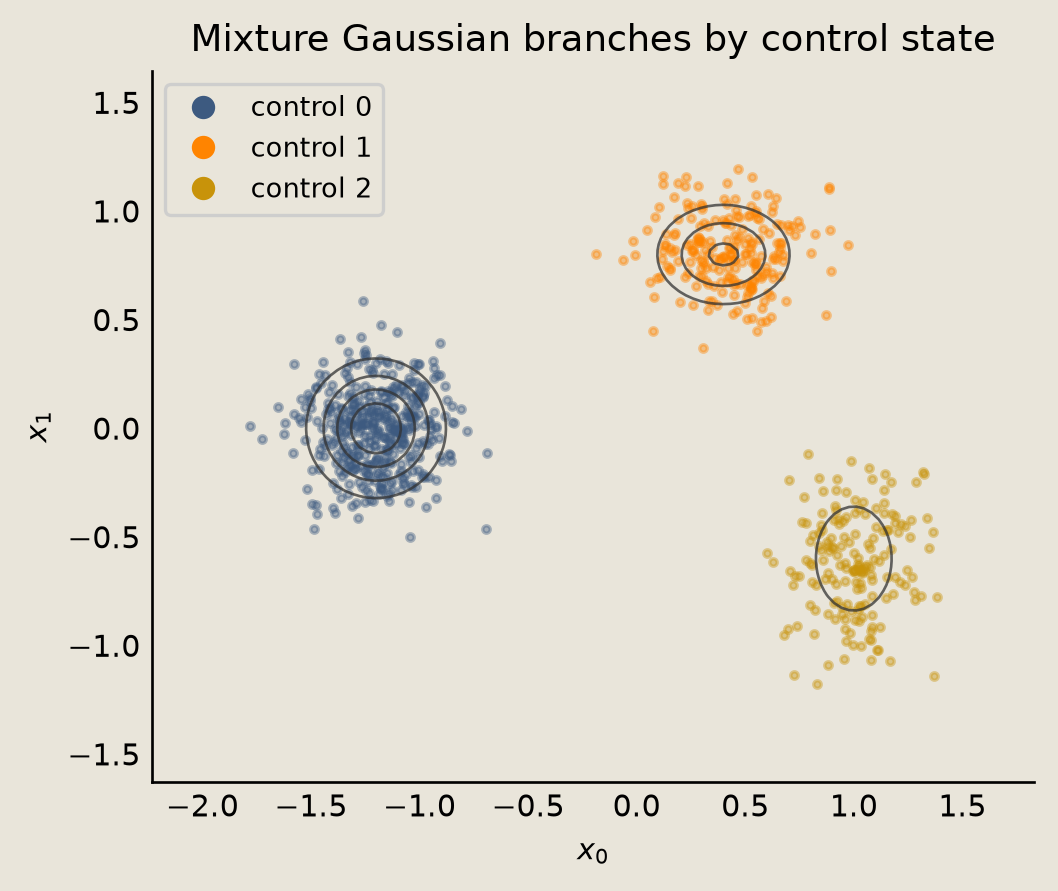

In [26]:
fig = P_fld.mixture_clouds(samples, labels)
xx, yy, zz = mixture_density_grid(mix_means, mix_sigmas, mix_probs, samples)
fig.axes[0].contour(xx, yy, zz, levels=5, colors="0.20", linewidths=0.8, alpha=0.75)
savefig(fig, "01_gate_mixture_gaussian")

The colored cloud is one marginal mixture sample: the control distribution chooses branch labels, and the contours show the analytic density from the same $\pi_k$, $\mu_k$, and $\Sigma_k$.

## Gate inventory

The table summarizes the gates we build in this tutorial, grouped by primitive.

Each gate is parametrised by a logit or a small parameter set, then composed through `DiscretePCircuit` or `HybridPCircuit`. The `Used in` column points to the notebooks that build each one.

The Torx gate library extends beyond this introductory set; for example, `PJUMP` is a two-pbit branch gate that moves probability from $|10)$ to $|01)$.

| Primitive | Gate | Role | Used in |
|---|---|---|---|
| Pbit | `PSWAP` | Two-pbit swap with probability $p$ | NB02, NB03 |
| Pbit | `PNOT` | Single-bit flip | NB04, NB06, NB07, NB08 |
| Pbit | `PISING` | $4 \times 4$ Glauber bond update | NB06, NB09 |
| Pdit | `PditCycle` | Stay/forward/backward walk on a cyclic $d$-state pdit | NB13 |
| Pmode | `AffineGaussianGate` | Affine transform and Gaussian noise | NB10, NB11 |
| Pmode | `MixtureGaussianGate` | Control-conditional Gaussian mixture | NB10, NB13, NB14 |

## Conclusion

In this tutorial, we built the basic parametrised stochastic circuits used by Torx.

- Torx programs act on three data primitives: pbits (binary), pdits ($d$-state), and pmodes (continuous, valued in $\mathbb{R}^N$).
- Discrete gates are column-stochastic kernels; pmode gates are continuous Markov kernels (Gaussian maps). Many discrete branch-table gates combine the identity with a deterministic operation selected with probability $p$, parametrised by the logit $\theta$ so they train with ordinary gradients. `PISING` uses a physical parameter vector instead.
- `PSWAP`, `PNOT`, and `PISING` are the core pbit gates, and `PditCycle` walks a cyclic $d$-state pdit (stay/forward/backward).
- `AffineGaussianGate` is an affine-Gaussian map, and `MixtureGaussianGate` selects one of several diagonal Gaussian components under a discrete control.

See also:

- [`02_random_walks_on_graphs.ipynb`](02_random_walks_on_graphs.ipynb), the `PSWAP` gate tiled over graph edges,
- [`06_ising_sampling_contrastive_divergence.ipynb`](06_ising_sampling_contrastive_divergence.ipynb), the `PISING` gate as a Gibbs sampler, and
- [`13_regime_switching_diffusion.ipynb`](13_regime_switching_diffusion.ipynb), the `PditCycle` gate and `MixtureGaussianGate` composed into one process.